# Imports

In [1]:
import os
import json
import pickle
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model import EvacuationModel

# Experiment Setup

In [2]:
# Create experiments directory structure
def create_experiment_structure():
    """Create directory structure for experiments."""
    base_dir = Path("experiments")
    base_dir.mkdir(exist_ok=True)
    return base_dir

def save_experiment_metadata(exp_dir, model_params, agent_params, description=""):
    """Save experiment configuration and metadata."""
    metadata = {
        "experiment_date": datetime.datetime.now().isoformat(),
        "description": description,
        "model_parameters": model_params,
        "agent_parameters": agent_params
    }
    
    with open(exp_dir / "experiment_config.json", "w") as f:
        json.dump(metadata, f, indent=2)
    
    print(f"Saved experiment metadata to {exp_dir / 'experiment_config.json'}")

def save_experiment_data(exp_dir, model_df, agent_df, final_model):
    """Save simulation results and final model state."""
    # Save dataframes as pickle
    with open(exp_dir / "model_data.pkl", "wb") as f:
        pickle.dump(model_df, f)
    
    with open(exp_dir / "agent_data.pkl", "wb") as f:
        pickle.dump(agent_df, f)
    
    
    print(f"Saved simulation data to {exp_dir}")
    print(f"  - model_data.pkl: {model_df.shape}")
    print(f"  - agent_data.pkl: {agent_df.shape}")
    
def load_experiment_results(exp_dir, load_detailed_data=False, parameter_filter=None):
    """
    Load results from a completed experiment with flexible data access.
    
    Args:
        exp_dir: Path to experiment directory
        load_detailed_data: If True, also load model/agent dataframes for each run
        parameter_filter: Dict to filter runs, e.g., {"v0": 2.0} or {"leader_proportion": 0.1}
    
    Returns:
        results_dict: Dictionary containing all experiment data
    """
    exp_dir = Path(exp_dir)
    
    # Load basic experiment info
    with open(exp_dir / "experiment_config.json", "r") as f:
        config = json.load(f)
    
    # Load summary and detailed results
    summary_df = pd.read_csv(exp_dir / "summary_results.csv")
    detailed_df = pd.read_csv(exp_dir / "detailed_results.csv")
    
    # Load raw results if available
    all_results = None
    if (exp_dir / "all_results.json").exists():
        with open(exp_dir / "all_results.json", "r") as f:
            all_results = json.load(f)
    
    print(f"Loaded experiment: {config['description']}")
    print(f"Date: {config['experiment_date']}")
    print(f"Total runs: {len(detailed_df)}")
    
    # Build results dictionary
    results = {
        "config": config,
        "summary_df": summary_df,
        "detailed_df": detailed_df,
        "all_results": all_results,
        "exp_dir": exp_dir
    }
    
    # Identify the varied parameter from the data
    varied_params = []
    for col in detailed_df.columns:
        if col not in ['run', 'total_time', 'evacuated', 'injured', 'evacuation_rate', 
                      'flow_rate', 'simulation_steps', 'computation_time', 
                      'final_agents_remaining', 'timeout']:
            if detailed_df[col].nunique() > 1:
                varied_params.append(col)
    
    if varied_params:
        print(f"Varied parameter(s): {', '.join(varied_params)}")
        results["varied_parameters"] = varied_params
    
    # Apply parameter filter if specified
    if parameter_filter:
        filtered_df = detailed_df.copy()
        for param, value in parameter_filter.items():
            if param in filtered_df.columns:
                filtered_df = filtered_df[filtered_df[param] == value]
                print(f"Filtered to {param} = {value}: {len(filtered_df)} runs")
            else:
                print(f"Warning: Parameter '{param}' not found in data")
        results["filtered_df"] = filtered_df
    
    # Load detailed simulation data if requested
    if load_detailed_data:
        print(f"Loading detailed simulation data...")
        detailed_data = load_simulation_data(exp_dir, parameter_filter)
        results["simulation_data"] = detailed_data
        print(f"Loaded simulation data for {len(detailed_data)} runs")
    
    return results

def load_simulation_data(exp_dir, parameter_filter=None):
    """
    Load model and agent dataframes for specific runs.
    
    Args:
        exp_dir: Path to experiment directory
        parameter_filter: Dict to filter which runs to load, e.g., {"v0": 2.0}
    
    Returns:
        simulation_data: Dict with run info and dataframes
    """
    exp_dir = Path(exp_dir)
    simulation_data = {}
    
    # Get all run directories
    run_dirs = [d for d in exp_dir.iterdir() if d.is_dir() and d.name.startswith(('v0_', 'leader_', 'param_'))]
    
    for run_dir in run_dirs:
        # Load run configuration
        run_config_file = run_dir / "run_config.json"
        if not run_config_file.exists():
            continue
            
        with open(run_config_file, "r") as f:
            run_config = json.load(f)
        
        # Apply filter if specified
        if parameter_filter:
            skip_run = False
            for param, value in parameter_filter.items():
                # Check in agent_params first, then model_params
                agent_value = run_config.get("agent_params", {}).get(param)
                model_value = run_config.get("model_params", {}).get(param)
                actual_value = run_config.get(param + "_actual")
                
                run_value = agent_value or model_value or actual_value
                
                if run_value != value:
                    skip_run = True
                    break
            
            if skip_run:
                continue
        
        # Load the dataframes
        model_data_file = run_dir / "model_data.pkl"
        agent_data_file = run_dir / "agent_data.pkl"
        
        run_data = {
            "run_config": run_config,
            "run_dir": run_dir,
            "run_name": run_dir.name
        }
        
        if model_data_file.exists():
            with open(model_data_file, "rb") as f:
                run_data["model_df"] = pickle.load(f)
        
        if agent_data_file.exists():
            with open(agent_data_file, "rb") as f:
                run_data["agent_df"] = pickle.load(f)
        
        simulation_data[run_dir.name] = run_data
    
    return simulation_data

# Baseline experiment

In [3]:
def run_baseline_experiment(v0_values=None, experiment_name="baseline", description="Helbing replication", n_runs=1):
    """
    Run baseline experiment to replicate Helbing's faster-is-slower effect.
    
    Args:
        v0_values: List of desired speeds to test. If None, uses default range.
        experiment_name: Name for this experiment
        description: Description of the experiment
        n_runs: Number of runs per v0 value (for averaging)
    """
    if v0_values is None:
        v0_values = [0.5, 0.8, 1.0, 1.3, 1.5, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]
    
    # Create experiment directory
    base_dir = create_experiment_structure()
    exp_dir = base_dir / f"{experiment_name}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    exp_dir.mkdir(exist_ok=True)
    
    print(f"Starting {experiment_name} experiment")
    print(f"Results will be saved to: {exp_dir}")
    print(f"Testing {len(v0_values)} different v0 values")
    print(f"Running {n_runs} simulation(s) per v0 value")
    
    # Model parameters (Helbing configuration)
    model_params = {
        "n_agents": 50,
        "width": 15.0,
        "height": 15.0,
        "exit_width": 2.0,
        "num_exits": 1,
        "dt": 0.1,
        "integration_method": "euler",
        "agent_type": "simple",
        "enable_fire": False,  # Disable fire for baseline
        "max_steps": 1000,    # 100 seconds at dt=0.1
        "exit_preset": "center_right"
    }

    base_agent_params = {
        "v0": 1.3,  # Will be overridden per experiment
    }
    
    # Save experiment configuration
    save_experiment_metadata(exp_dir, model_params, base_agent_params, description)
    
    # Results storage
    all_results = []
    
    total_simulations = len(v0_values) * n_runs
    current_sim = 0
    
    for i, v0 in enumerate(v0_values):
        print(f"\n--- Testing v0 = {v0:.1f} m/s ({i+1}/{len(v0_values)}) ---")
        
        v0_results = []  # Store results for this v0 across multiple runs
        
        for run in range(n_runs):
            current_sim += 1
            if n_runs > 1:
                print(f"  Run {run+1}/{n_runs} (Overall: {current_sim}/{total_simulations})")
            
            # Update agent parameters for this run
            agent_params = base_agent_params.copy()
            agent_params["v0"] = v0
            
            # Create model with fixed exit
            model = EvacuationModel(
                agent_parameters=agent_params,
                seed=42 + run,  # Different seed for each run
                **{k: v for k, v in model_params.items() if k not in ["max_steps"]}
            )
            
            # Run simulation
            start_time = datetime.datetime.now()
            
            for step in range(model_params["max_steps"]):
                if step % 2000 == 0 and step > 0:
                    remaining = len([a for a in model.agents if getattr(a, "is_pedestrian", False)])
                    elapsed = step * model.dt
                    print(f"    Step {step} ({elapsed:.1f}s): {remaining} agents remaining")
                
                model.step()
                
                if not model.running:
                    print(f"Completed at step {step} ({step * model.dt:.1f}s)")
                    break
            
            end_time = datetime.datetime.now()
            simulation_duration = (end_time - start_time).total_seconds()
            
            # Get results
            model_df = model.datacollector.get_model_vars_dataframe()
            agent_df = model.datacollector.get_agent_vars_dataframe()
            
            # Calculate metrics
            total_time = len(model_df) * model.dt
            evacuated = model.n_agents - len([a for a in model.agents if getattr(a, "is_pedestrian", False)])
            injured = len([a for a in model.agents if getattr(a, "is_pedestrian", False) and getattr(a, "injured", False)])
            
            # Average flow rate (agents per second)
            if total_time > 0:
                flow_rate = evacuated / total_time
            else:
                flow_rate = 0
            
            result = {
                "v0": v0,
                "run": run,
                "total_time": total_time,
                "evacuated": evacuated,
                "injured": injured,
                "evacuation_rate": evacuated / model.n_agents,
                "flow_rate": flow_rate,
                "simulation_steps": len(model_df),
                "computation_time": simulation_duration,
                "final_agents_remaining": len([a for a in model.agents if getattr(a, "is_pedestrian", False)]),
                "timeout": len(model_df) >= model_params["max_steps"]
            }
            
            v0_results.append(result)
            all_results.append(result)
            
            # Save individual run data
            run_dir = exp_dir / f"v0_{v0:.1f}_run_{run}"
            run_dir.mkdir(exist_ok=True)
            save_experiment_data(run_dir, model_df, agent_df, model)
            
            # Save run-specific parameters
            run_config = {
                "model_params": model_params,
                "agent_params": agent_params,
                "v0_actual": v0,
                "run_number": run,
                "seed": 42 + run
            }
            with open(run_dir / "run_config.json", "w") as f:
                json.dump(run_config, f, indent=2)
        
        # Calculate statistics for this v0 across runs
        if n_runs > 1:
            avg_time = np.mean([r["total_time"] for r in v0_results])
            std_time = np.std([r["total_time"] for r in v0_results])
            avg_flow = np.mean([r["flow_rate"] for r in v0_results])
            
            print(f"v0={v0:.1f}: {avg_time:.1f}±{std_time:.1f}s, flow={avg_flow:.2f} agents/s")
        else:
            print(f"v0={v0:.1f}: {v0_results[0]['total_time']:.1f}s, flow={v0_results[0]['flow_rate']:.2f} agents/s")

    # Save summary results
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(exp_dir / "detailed_results.csv", index=False)
    
    # Create aggregated summary (mean across runs)
    if n_runs > 1:
        summary_stats = []
        for v0 in v0_values:
            v0_data = results_df[results_df['v0'] == v0]
            summary_stats.append({
                'v0': v0,
                'total_time_mean': v0_data['total_time'].mean(),
                'total_time_std': v0_data['total_time'].std(),
                'flow_rate_mean': v0_data['flow_rate'].mean(),
                'flow_rate_std': v0_data['flow_rate'].std(),
                'evacuation_rate_mean': v0_data['evacuation_rate'].mean(),
                'injured_mean': v0_data['injured'].mean(),
                'timeout_rate': v0_data['timeout'].mean(),
                'n_runs': len(v0_data)
            })
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_csv(exp_dir / "summary_results.csv", index=False)
    else:
        # For single runs, summary is the same as detailed
        summary_df = results_df.copy()
        summary_df.to_csv(exp_dir / "summary_results.csv", index=False)
    
    # Save raw results
    with open(exp_dir / "all_results.json", "w") as f:
        json.dump(all_results, f, indent=2)
    
    print(f"\nExperiment completed!")
    print(f"All results saved to: {exp_dir}")
    print(f"Summary: {len(v0_values)} v0 values × {n_runs} runs = {len(all_results)} total simulations")

    return summary_df, exp_dir, all_results

## Quick test
- here I ran it twice with 1 replication per condition and with 2 to make sure that the code behaves the same and ensure we get the same results given the same seed.

In [ ]:
# Experiment 1: Quick validation (3 v0 values, single run)
print("Experiment 1: Quick Validation")
v0_quick = [1.0, 2.0, 3.0]
results_quick, exp_dir_quick, _ = run_baseline_experiment(
    v0_values=v0_quick,
    experiment_name="quick_validation",
    description="Quick test with 3 v0 values to validate setup",
    n_runs=2
)

### Example1: How to load general experimnet data

In [4]:
results = load_experiment_results("experiments/quick_validation_20251019_132004")

Loaded experiment: Quick test with 3 v0 values to validate setup
Date: 2025-10-19T13:20:04.767505
Total runs: 6
Varied parameter(s): v0


In [5]:
print("Configuration:")
print(results['config'])

print("\nSummary DataFrame:")
display(results['summary_df'])

print("\nDetailed DataFrame:")
display(results['detailed_df'])

print("\nAll Results:")
display(results['all_results'])

Configuration:
{'experiment_date': '2025-10-19T13:20:04.767505', 'description': 'Quick test with 3 v0 values to validate setup', 'model_parameters': {'n_agents': 200, 'width': 15.0, 'height': 15.0, 'exit_width': 1.0, 'num_exits': 1, 'dt': 0.1, 'integration_method': 'euler', 'agent_type': 'simple', 'enable_fire': False, 'max_steps': 1000, 'exit_preset': 'center_right'}, 'agent_parameters': {'v0': 1.3}}

Summary DataFrame:


,v0,total_time_mean,total_time_std,flow_rate_mean,flow_rate_std,evacuation_rate_mean,injured_mean,timeout_rate,n_runs
0,1.0,100.00,0.000000,1.540000,0.042426,0.77,0.0,1.0,2
1,2.0,84.45,3.889087,2.370779,0.109179,1.00,0.0,0.0,2
2,3.0,65.15,2.474874,3.072055,0.116699,1.00,0.0,0.0,2



Detailed DataFrame:


,v0,run,total_time,evacuated,injured,evacuation_rate,flow_rate,simulation_steps,computation_time,final_agents_remaining,timeout
0,1.0,0,100.0,157,0,0.785,1.570000,1000,79.253922,43,True
1,1.0,1,100.0,151,0,0.755,1.510000,1000,101.554780,49,True
2,2.0,0,87.2,200,0,1.000,2.293578,872,60.115927,0,False
3,2.0,1,81.7,200,0,1.000,2.447980,817,52.876207,0,False
4,3.0,0,63.4,200,0,1.000,3.154574,634,47.079608,0,False
5,3.0,1,66.9,200,0,1.000,2.989537,669,52.625414,0,False



All Results:


[{'v0': 1.0,
  'run': 0,
  'total_time': 100.0,
  'evacuated': 157,
  'injured': 0,
  'evacuation_rate': 0.785,
  'flow_rate': 1.57,
  'simulation_steps': 1000,
  'computation_time': 79.253922,
  'final_agents_remaining': 43,
  'timeout': True},
 {'v0': 1.0,
  'run': 1,
  'total_time': 100.0,
  'evacuated': 151,
  'injured': 0,
  'evacuation_rate': 0.755,
  'flow_rate': 1.51,
  'simulation_steps': 1000,
  'computation_time': 101.55478,
  'final_agents_remaining': 49,
  'timeout': True},
 {'v0': 2.0,
  'run': 0,
  'total_time': 87.2,
  'evacuated': 200,
  'injured': 0,
  'evacuation_rate': 1.0,
  'flow_rate': 2.293577981651376,
  'simulation_steps': 872,
  'computation_time': 60.115927,
  'final_agents_remaining': 0,
  'timeout': False},
 {'v0': 2.0,
  'run': 1,
  'total_time': 81.7,
  'evacuated': 200,
  'injured': 0,
  'evacuation_rate': 1.0,
  'flow_rate': 2.4479804161566707,
  'simulation_steps': 817,
  'computation_time': 52.876207,
  'final_agents_remaining': 0,
  'timeout': False

### Example 2: How to load detailed experimnet data

In [6]:

results_v0_2 = load_experiment_results(
    "experiments/quick_validation_20251019_132004",
    load_detailed_data=True,
    parameter_filter={"v0": 2.0}
)

Loaded experiment: Quick test with 3 v0 values to validate setup
Date: 2025-10-19T13:20:04.767505
Total runs: 6
Varied parameter(s): v0
Filtered to v0 = 2.0: 2 runs
Loading detailed simulation data...
Loaded simulation data for 2 runs


In [7]:
# All of the above shown data is still accessible
# If you use a parameter filter: e.g. parameter_filter={"v0": 2.0} - then you can access a filtered_df that shows data for that specific parameter only
display(results_v0_2['filtered_df'])

# In addition if load_detailed_data is True then you could also access the individual model and agent dataframes for specific visualizations
# Access individual run data
run_0_data = results_v0_2['simulation_data']['v0_2.0_run_0']
run_1_data = results_v0_2['simulation_data']['v0_2.0_run_1']

# Get the model dataframes
model_df_run0 = run_0_data['model_df']
model_df_run1 = run_1_data['model_df']

# Get the agent dataframes  
agent_df_run0 = run_0_data['agent_df']
agent_df_run1 = run_1_data['agent_df']

# Print shapes to see the data
print(f"Run 0 - Model data: {model_df_run0.shape}, Agent data: {agent_df_run0.shape}")
print(f"Run 1 - Model data: {model_df_run1.shape}, Agent data: {agent_df_run1.shape}")

display(model_df_run0.head(5))
display(agent_df_run0.head(5))

,v0,run,total_time,evacuated,injured,evacuation_rate,flow_rate,simulation_steps,computation_time,final_agents_remaining,timeout
2,2.0,0,87.2,200,0,1.0,2.293578,872,60.115927,0,False
3,2.0,1,81.7,200,0,1.0,2.447980,817,52.876207,0,False


Run 0 - Model data: (872, 24), Agent data: (74133, 14)
Run 1 - Model data: (817, 24), Agent data: (67863, 14)


,Agents,Average_Speed,Exit_Flow_Total,Exit0_Flow,Exit1_Flow,Exit2_Flow,Exit_Balance_Entropy,Exit0_Pressure,Exit1_Pressure,Exit2_Pressure,...,Injured_Total,Injured_Fire,Injured_Smoke,Injured_Press,Std_v0_init,Std_vmax,Std_radius,Std_mass,Std_vis,Std_panic0
0,200,0.636531,0,0,0,0,0.0,79.575710,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
1,200,0.998301,0,0,0,0,0.0,52.909412,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
2,200,1.283559,0,0,0,0,0.0,200.783293,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
3,200,1.579458,0,0,0,0,0.0,175.510914,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
4,199,1.849826,1,1,0,0,-0.0,468.905321,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0


is_pedestrian  is_leader  injured injury_cause  knows_exit  \
Step AgentID                                                               
1    0                 True      False    False         None       False   
     1                 True      False    False         None       False   
     2                 True      False    False         None       False   
     3                 True      False    False         None       False   
     4                 True      False    False         None       False   

             follow_target_id  smoke_exposure  panic  impatience          x  \
Step AgentID                                                                  
1    0                   None             0.0    0.0         0.0   0.867326   
     1                   None             0.0    0.0         0.0  10.890441   
     2                   None             0.0    0.0         0.0   1.933661   
     3                   None             0.0    0.0         0.0   3.504856   
     4                   None             0.0    0.0         0.0   3.322923   

                     y        vx        vy     Speed  
Step AgentID                                          
1    0        4.375339  0.171753  0.249290  0.302729  
     1        9.984561  0.798444  0.107686  0.805673  
     2        6.389483  2.165178 -0.174230  2.172177  
     3        7.587946 -0.560760  0.129716  0.575568  
     4        9.595591  0.391957 -0.027916  0.392950

In [21]:
print(agent_df_run0.columns)
print(model_df_run0.columns)

Index(['is_pedestrian', 'is_leader', 'injured', 'injury_cause', 'knows_exit',
       'follow_target_id', 'smoke_exposure', 'panic', 'impatience', 'x', 'y',
       'vx', 'vy', 'Speed'],
      dtype='object')
Index(['Agents', 'Average_Speed', 'Exit_Flow_Total', 'Exit0_Flow',
       'Exit1_Flow', 'Exit2_Flow', 'Exit_Balance_Entropy', 'Exit0_Pressure',
       'Exit1_Pressure', 'Exit2_Pressure', 'Followers_Latched',
       'Leaders_Remaining', 'Mean_VisTerm', 'Mean_SmokeExposure',
       'Injured_Total', 'Injured_Fire', 'Injured_Smoke', 'Injured_Press',
       'Std_v0_init', 'Std_vmax', 'Std_radius', 'Std_mass', 'Std_vis',
       'Std_panic0'],
      dtype='object')


## Full SImple Agent experiment

In [8]:
# Full Helbing experiment (default v0 range, single run)
print("Experiment 2: Full Helbing replication with 3 replicates per condition")
v0_helbing_complete = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
results_full, exp_dir_full, _ = run_baseline_experiment(
    v0_values=v0_helbing_complete,
    experiment_name="full_Helbing_replication",
    description="Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition",
    n_runs=3
)

Experiment 2: Full Helbing replication with 3 replicates per condition
Starting full_Helbing_replication experiment
Results will be saved to: experiments\full_Helbing_replication_20251020_092105
Testing 20 different v0 values
Running 3 simulation(s) per v0 value
Saved experiment metadata to experiments\full_Helbing_replication_20251020_092105\experiment_config.json

--- Testing v0 = 0.5 m/s (1/20) ---
  Run 1/3 (Overall: 1/60)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Saved simulation data to experiments\full_Helbing_replication_20251020_092105\v0_0.5_run_0
  - model_data.pkl: (1000, 24)
  - agent_data.pkl: (29998, 14)
  Run 2/3 (Overall: 2/60)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Radial pressure: 2243.1488231075373 for agent 26
Agent forces: 1958.5612769278011, -3032.2953363310357
Wall forces: -0.002712335746241609, 1.8077317494213506e-05
Agent repulsion force = 667.9494821140111
Radial pressure: 2220.4669189191072 for agent 40
Agent forces: 4255.352467517949, 1626.0672903078907
Wall forces: -98.02556875097702, 0.0009823405271574938
Agent repulsion force = 666.4145341232884
Saved simulation data to experiments\full_Helbing_replication_20251020_092105\v0_0.5_run_1
  - model_data.pkl: (1000, 24)
  - agent_data.pkl: (30023, 14)
  Run 3/3 (Overall: 3/60)


...

Radial pressure: 2471.2385029708494 for agent 4
Agent forces: 2778.762789687052, -3181.4247361716752
Wall forces: -4.300647557463343e-06, -0.00018577589962056343
Agent repulsion force = 303.8992558068366
Radial pressure: 5384.567244808275 for agent 27
Agent forces: -3850.308922224995, -8649.489699691183
Wall forces: -0.0001937700846432246, 6.8750256669268226e-06
Agent repulsion force = 391.7035611297809
Radial pressure: 13069.559805609657 for agent 8
Agent forces: -22441.177262975343, -7426.473243637971
Wall forces: -5.792764540870663e-06, -0.0010391759501846092
Agent repulsion force = 671.1118514185476
Radial pressure: 19723.916665580724 for agent 15
Agent forces: -19411.926586761525, -32533.20217190273
Wall forces: -0.042561118588634754, -0.00010975342817928958
Agent repulsion force = 765.5999469277469
Radial pressure: 8617.623303824 for agent 1
Agent forces: 2850.448703057794, 17290.862633626268
Wall forces: -0.0168965714363187, -6.76566125014481e-05
Agent repulsion force = 352.1632

c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Radial pressure: 7602.958711599274 for agent 45
Agent forces: -12987.21471862552, 3222.457575355685
Wall forces: -42.05921892041835, -0.01314570264456301
Agent repulsion force = 577.8090038097996
Radial pressure: 14530.328630856446 for agent 20
Agent forces: -793.5253270573097, 27358.16217513687
Wall forces: -69.6546025598342, 0.0055667444205411325
Agent repulsion force = 531.3569519839285
Radial pressure: 3246.992483710062 for agent 33
Agent forces: -3693.580970329505, -4260.23387455276
Wall forces: -13.862579616866794, -0.07730489847930472
Agent repulsion force = 688.5090788945786
Radial pressure: 26060.632584398823 for agent 27
Agent forces: -38409.2912237741, 29793.105718408755
Wall forces: -870.6764039887213, 0.04013433994719787
Agent repulsion force = 870.6720565775189
Radial pressure: 53586.18702852676 for agent 22
Agent forces: -96892.0836512245, -10988.975840076875
Wall forces: -285.663485848256, -4.220390813083564
Agent repulsion force = 456.1924499016334
Radial pressure: 696

c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Radial pressure: 15090.604983060659 for agent 40
Agent forces: -14811.983374270723, 22971.13954260278
Wall forces: -795.7688323573293, 0.009678817551523293
Agent repulsion force = 795.7679199038653
Radial pressure: 11527.557922190279 for agent 36
Agent forces: -8200.762189109486, -21513.5391692505
Wall forces: -2.4627801906036835, -0.011105796438837573
Agent repulsion force = 656.2284436989796
Radial pressure: 12971.294359577585 for agent 24
Agent forces: -8045.468247887442, 19377.44995200418
Wall forces: -6.704429362176761e-06, 3.364334093988634e-07
Agent repulsion force = 847.1778472221049
Radial pressure: 2197.855741085969 for agent 32
Agent forces: 4237.3304599580215, -1188.0403139721125
Wall forces: -1.1533518916602333e-06, 2.2793515201256274e-05
Agent repulsion force = 714.8998222392473
Radial pressure: 1665.1717709360253 for agent 46
Agent forces: 3030.228085110705, -735.4789901767377
Wall forces: -0.009369951455997963, 1.0898302922397134e-05
Agent repulsion force = 324.84459741

### Plots

In [20]:
def create_focused_helbing_plots(exp_dir, save_plots=False):
    """
    Create focused Helbing visualizations showing injuries and evacuation success.
    
    Args:
        exp_dir: Path to experiment directory
        save_plots: Whether to save plots to files
    """
    # Load the experiment results
    results = load_experiment_results(exp_dir)
    
    # Determine if we have multiple runs (check for std columns)
    has_std = 'total_time_std' in results['summary_df'].columns
    
    # Set up the plotting style
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'axes.linewidth': 1.5,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'lines.linewidth': 2.5,
        'lines.markersize': 8
    })
    
    # Create figure with 1x2 layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Number of Injuries vs Desired Speed
    if has_std:
        injured_col = 'injured_mean'
        injured_std = results['summary_df'].get('injured_std', None)
        
        if injured_std is not None:
            ax1.errorbar(results['summary_df']['v0'], 
                        results['summary_df'][injured_col],
                        yerr=injured_std,
                        fmt='o-', color='red', linewidth=2.5, markersize=8,
                        capsize=5, capthick=2, label='Number of Injured People')
        else:
            ax1.plot(results['summary_df']['v0'], 
                    results['summary_df'][injured_col],
                    'o-', color='red', linewidth=2.5, markersize=8,
                    label='Number of Injured People')
    else:
        injured_col = 'injured'
        ax1.plot(results['summary_df']['v0'], 
                results['summary_df'][injured_col],
                'o-', color='red', linewidth=2.5, markersize=8,
                label='Number of Injured People')
    
    ax1.set_xlabel('Desired Velocity v₀ (m/s)')
    ax1.set_ylabel('Number of Injured People')
    ax1.set_title('(a) Injuries vs Desired Speed\n(100-second simulation)')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, max(results['summary_df']['v0']) + 0.5)
    ax1.set_ylim(bottom=0)
    
    # Plot 2: Evacuation Rate Only
    if has_std:
        evac_rate = results['summary_df']['evacuation_rate_mean'] * 100
        
        evac_std = results['summary_df'].get('evacuation_rate_std', None)
        if evac_std is not None:
            evac_rate_std = evac_std * 100
            ax2.errorbar(results['summary_df']['v0'], evac_rate,
                        yerr=evac_rate_std,
                        fmt='o-', color='blue', linewidth=2.5, markersize=8,
                        capsize=5, capthick=2, label='Evacuation Rate')
        else:
            ax2.plot(results['summary_df']['v0'], evac_rate,
                    'o-', color='blue', linewidth=2.5, markersize=8,
                    label='Evacuation Rate')
    else:
        evac_rate = results['summary_df']['evacuation_rate'] * 100
        ax2.plot(results['summary_df']['v0'], evac_rate,
                'o-', color='blue', linewidth=2.5, markersize=8,
                label='Evacuation Rate')
    
    ax2.set_xlabel('Desired Velocity v₀ (m/s)')
    ax2.set_ylabel('Evacuation Success Rate (%)')
    ax2.set_title('(b) Evacuation Success vs Desired Speed\n(100-second simulation)')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, max(results['summary_df']['v0']) + 0.5)
    ax2.set_ylim(0, 105)
    
    plt.tight_layout()
    
    if save_plots:
        plot_path = Path(exp_dir) / "focused_helbing_plots.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    plt.show()

- in the plot we see that as the desired speed increase past 1.5 m/s less and less people are able to evacuate (faster is slower effect). In the same time more and more people get injured.

Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0


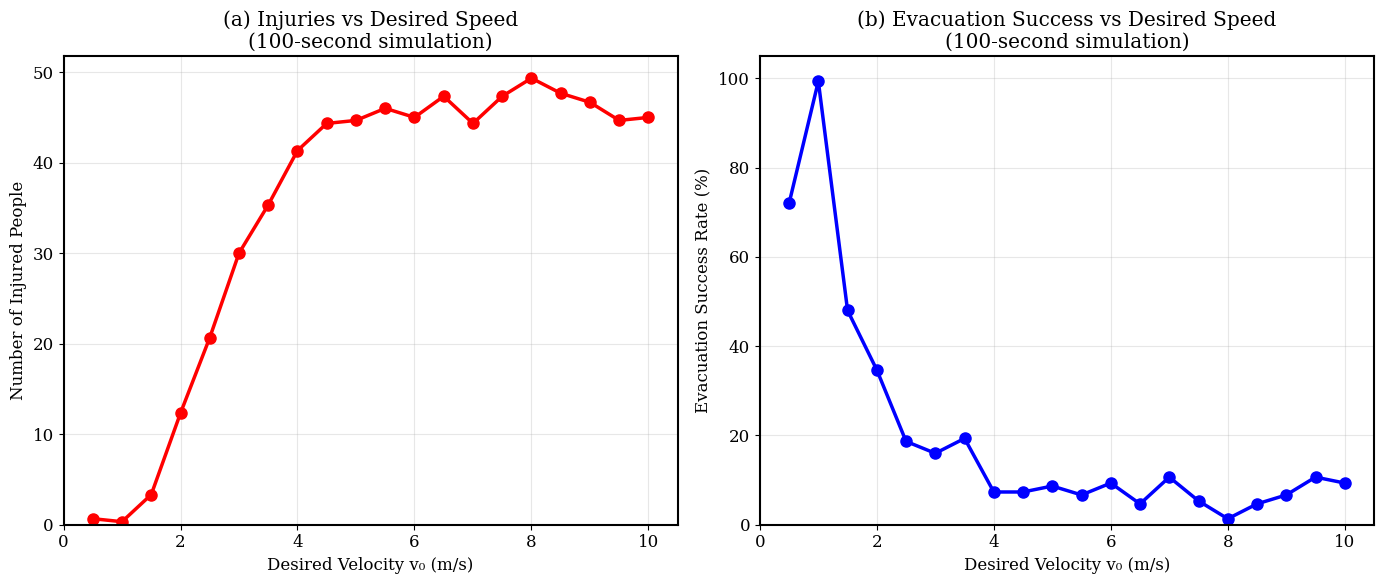

In [22]:
create_focused_helbing_plots("experiments/full_Helbing_replication_20251020_092105", save_plots=True)

In [37]:
def create_agent_leaving_times_plot(exp_dir, save_plots=False):
    """
    Alternative approach: Use agent position data to determine when agents left.
    """
    results = load_experiment_results(exp_dir)
    v0_values = sorted(results['summary_df']['v0'].unique())
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    all_leaving_times = []
    all_v0_values = []
    
    for v0 in v0_values:
        print(f"Processing v0 = {v0:.1f} m/s...")
        
        v0_results = load_experiment_results(
            exp_dir, load_detailed_data=True, parameter_filter={"v0": v0}
        )
        
        v0_leaving_times = []
        
        for run_name, run_data in v0_results['simulation_data'].items():
            if 'agent_df' not in run_data:
                continue
                
            agent_df = run_data['agent_df']
            dt = 0.1
            
            # Get unique agent IDs
            agent_ids = agent_df.index.get_level_values('AgentID').unique()
            
            for agent_id in agent_ids:
                try:
                    # Get this agent's data over time
                    agent_data = agent_df.xs(agent_id, level='AgentID')
                    
                    # Agent left when they disappear from the data OR reach exit
                    # Simple approach: use last recorded step
                    last_step = agent_data.index.max()
                    leaving_time = last_step * dt
                    
                    # Only include if agent actually evacuated (not just simulation ended)
                    if leaving_time < 100.0:  # Less than max simulation time
                        v0_leaving_times.append(leaving_time)
                        
                except Exception as e:
                    continue
        
        all_leaving_times.extend(v0_leaving_times)
        all_v0_values.extend([v0] * len(v0_leaving_times))
    
    # Plot
    all_leaving_times = np.array(all_leaving_times)
    all_v0_values = np.array(all_v0_values)
    
    for v0 in v0_values:
        mask = all_v0_values == v0
        times = all_leaving_times[mask]
        v0_array = np.full_like(times, v0)
        
        jitter = np.random.normal(0, 0.05, size=len(times))
        v0_jittered = v0_array + jitter
        
        color = 'green' if v0 in [0.5, 1.0] else 'red'
        ax.scatter(v0_jittered, times, c=color, marker='+', s=30, alpha=0.7)
    
    ax.set_xlabel('Desired Velocity v₀ (m/s)')
    ax.set_ylabel('Leaving Time T (s)')
    ax.set_title('Individual Agent Leaving Times vs Desired Speed for all 3 runs')
    ax.grid(True, alpha=0.3)
    
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='+', color='green', linestyle='None',
               markersize=10, markeredgewidth=2, label='v₀ = 0.5, 1.0 m/s'),
        Line2D([0], [0], marker='+', color='red', linestyle='None',
               markersize=10, markeredgewidth=2, label='v₀ ≥ 1.5 m/s')
    ]
    ax.legend(handles=legend_elements)
    
    plt.tight_layout()
    if save_plots:
        plot_path = Path(exp_dir) / "agent_leaving_times_plot.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

- we see that as the desired speed increases - agents tend to get injured near the exit resultsing at a bottleneck that prevents other agents from leaving

Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Processing v0 = 0.5 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 0.5: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.0 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 1.0: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.5 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5

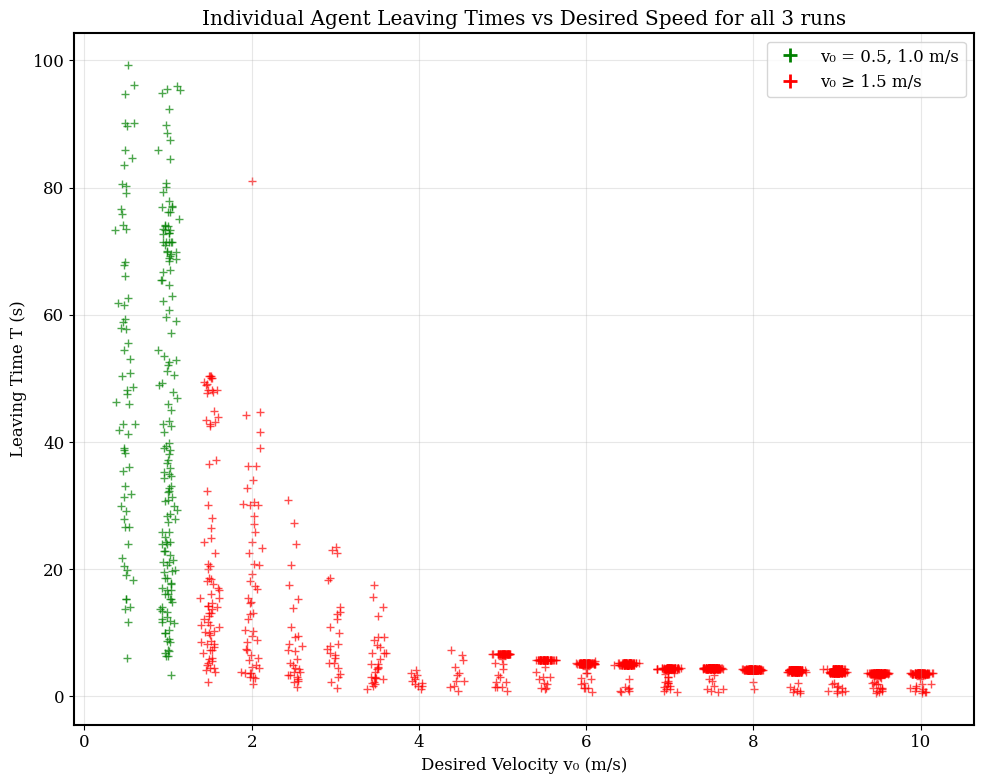

In [35]:
create_agent_leaving_times_plot("experiments/full_Helbing_replication_20251020_092105", save_plots=True)